# QM Ch 5 — Identical Particles: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

| Fig | File | Topic | Slide |
|-----|------|-------|-------|
| 1 | `ch05_fig1_exchange.png` | Exchange interaction — bosons vs fermions vs distinguishable | §5.1 |
| 2 | `ch05_fig2_fermi_band.png` | Free electron gas: Fermi sphere, DOS, band structure | §5.3 |
| 3 | `ch05_fig3_distributions.png` | FD, BE, MB distributions vs temperature | §5.4 |

In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import zeta

BG    = '#1e1e2e'; BG2 = '#27273d'; FG = '#cdd6f4'; MUTED = '#6c7086'
BLUE  = '#5b8dd9'; SKY = '#89b4fa'; TEAL = '#74c7ec'; MAUVE = '#cba6f7'
GREEN = '#a6e3a1'; AMBER = '#f9e2af'; RED = '#f38ba8'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  BG2,
    'axes.edgecolor':   MUTED,'axes.labelcolor': FG,
    'xtick.color':      MUTED,'ytick.color':     MUTED,
    'text.color':       FG,   'grid.color':      '#313244',
    'grid.linewidth':   0.5,  'grid.alpha':      0.5,
    'font.family':      'sans-serif','font.size': 11,
    'axes.titlesize':   12,   'axes.titleweight':'bold',
    'axes.labelsize':   10,   'legend.fontsize': 9,
    'legend.facecolor': BG2,  'legend.edgecolor':MUTED,
    'lines.linewidth':  2.0,  'figure.dpi':      130,
})
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)
print('Setup complete.')

Setup complete.


## Fig 1 — Exchange Interaction: Bosons vs Fermions vs Distinguishable (§5.1)

<(x1-x2)²>  (numerical vs analytic):
  Distinguishable: 0.103341  exact: 0.103341
  Bosons:          0.038450  exact: 0.038450
  Fermions:        0.168232  exact: 0.168232
  Exchange term 2|<ψ_a|x|ψ_b>|²: 0.064891
  Bosons closer (< dist): True ✓
  Fermions farther (> dist): True ✓


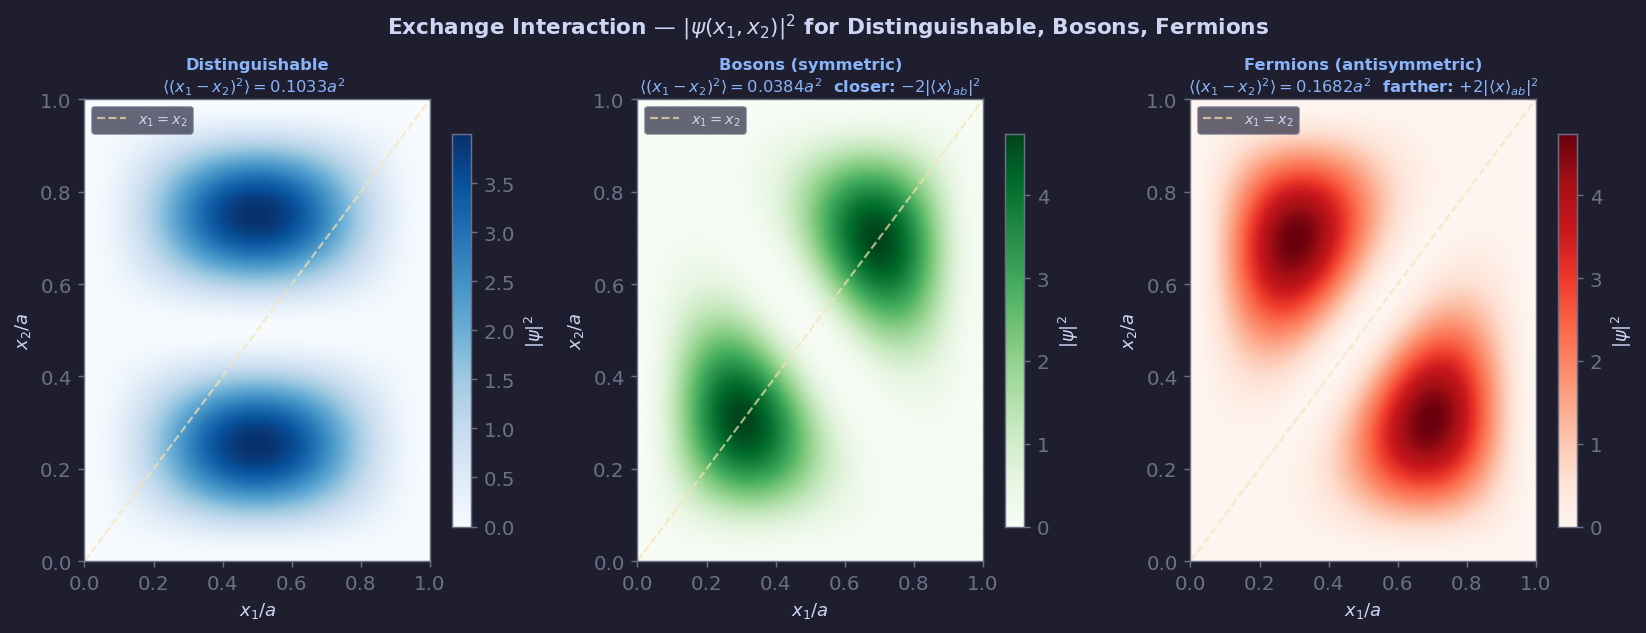

Fig 1 saved.


In [2]:
# Two particles in an infinite square well [0,a], single-particle states ψ₁, ψ₂
# ψ_n(x) = √(2/a) sin(nπx/a)
#
# Two-particle probability densities |ψ(x1,x2)|²:
#   Distinguishable:  ψ_a(x1)ψ_b(x2)
#   Bosons:           [ψ_a(x1)ψ_b(x2) + ψ_b(x1)ψ_a(x2)] / √2
#   Fermions:         [ψ_a(x1)ψ_b(x2) - ψ_b(x1)ψ_a(x2)] / √2
#
# Physics check:
#   <(x1-x2)²> = <x²>_a + <x²>_b - 2<x>_a<x>_b ∓ 2|<ψ_a|x|ψ_b>|²
#   Fermions (−2): larger separation
#   Bosons  (+2): smaller separation

a = 1.0
N = 300
x = np.linspace(0, a, N)
dx = x[1] - x[0]

def psi(n, x, a=1.0):
    return np.sqrt(2/a) * np.sin(n*np.pi*x/a)

na, nb = 1, 2   # particle a in state 1, particle b in state 2
X1, X2 = np.meshgrid(x, x)

psi_a1 = psi(na, X1); psi_b2 = psi(nb, X2)
psi_b1 = psi(nb, X1); psi_a2 = psi(na, X2)

prob_dist   = (psi_a1 * psi_b2)**2
prob_boson  = 0.5*(psi_a1*psi_b2 + psi_b1*psi_a2)**2
prob_fermion= 0.5*(psi_a1*psi_b2 - psi_b1*psi_a2)**2

# <(x1-x2)²> via numerical integration
diff2 = (X1 - X2)**2
def mean_sep(prob):
    return np.sum(prob * diff2) * dx**2

sep_dist    = mean_sep(prob_dist)
sep_boson   = mean_sep(prob_boson)
sep_fermion = mean_sep(prob_fermion)

# Exact analytic: <x²>_n = a²(1/3 - 1/(2n²π²)),  <x>_n = a/2
x2_1 = a**2*(1/3 - 1/(2*(na*np.pi)**2))
x2_2 = a**2*(1/3 - 1/(2*(nb*np.pi)**2))
x_1  = a/2;  x_2 = a/2   # <x> = a/2 for all n (symmetric well)
# <ψ_1|x|ψ_2> = ∫ ψ_1 x ψ_2 dx
xab = np.trapezoid(psi(na,x) * x * psi(nb,x), x)
sep_exact_dist    = x2_1 + x2_2 - 2*x_1*x_2
sep_exact_boson   = sep_exact_dist - 2*xab**2
sep_exact_fermion = sep_exact_dist + 2*xab**2

print(f'<(x1-x2)²>  (numerical vs analytic):')
print(f'  Distinguishable: {sep_dist:.6f}  exact: {sep_exact_dist:.6f}')
print(f'  Bosons:          {sep_boson:.6f}  exact: {sep_exact_boson:.6f}')
print(f'  Fermions:        {sep_fermion:.6f}  exact: {sep_exact_fermion:.6f}')
print(f'  Exchange term 2|<ψ_a|x|ψ_b>|²: {2*xab**2:.6f}')
print(f'  Bosons closer (< dist): {sep_boson < sep_dist} ✓')
print(f'  Fermions farther (> dist): {sep_fermion > sep_dist} ✓')

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.06, right=0.97, wspace=0.28))
fig.suptitle(r'Exchange Interaction — $|\psi(x_1,x_2)|^2$ for Distinguishable, Bosons, Fermions',
             color=FG, fontsize=12, fontweight='bold', y=0.99)

configs = [
    (prob_dist,    'Distinguishable',  sep_dist,    BLUE,  ''),
    (prob_boson,   'Bosons (symmetric)',sep_boson,   GREEN, r'closer: $-2|\langle x\rangle_{ab}|^2$'),
    (prob_fermion, 'Fermions (antisymmetric)',sep_fermion,RED, r'farther: $+2|\langle x\rangle_{ab}|^2$'),
]

for ax, (prob, title, sep, col, note) in zip(axes, configs):
    im = ax.imshow(prob, extent=[0,a,0,a], origin='lower',
                   cmap='Blues' if col==BLUE else ('Greens' if col==GREEN else 'Reds'),
                   aspect='auto', vmin=0)
    # Diagonal x1=x2 line
    ax.plot([0,a],[0,a], color=AMBER, lw=1.2, ls='--', alpha=0.7, label=r'$x_1=x_2$')
    ax.set_xlabel(r'$x_1/a$'); ax.set_ylabel(r'$x_2/a$')
    ax.set_title(f'{title}\n'
                 fr'$\langle(x_1-x_2)^2\rangle={sep:.4f}a^2$  {note}',
                 color=SKY, fontsize=9, pad=4)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.7)
    plt.colorbar(im, ax=ax, shrink=0.85, label=r'$|\psi|^2$')

fig.subplots_adjust(top=0.85)
plt.savefig('ch05_fig1_exchange.png', **SAVEKW)
plt.show()
print('Fig 1 saved.')

## Fig 2 — Free Electron Gas: Fermi Sphere, DOS, Band Structure (§5.3)

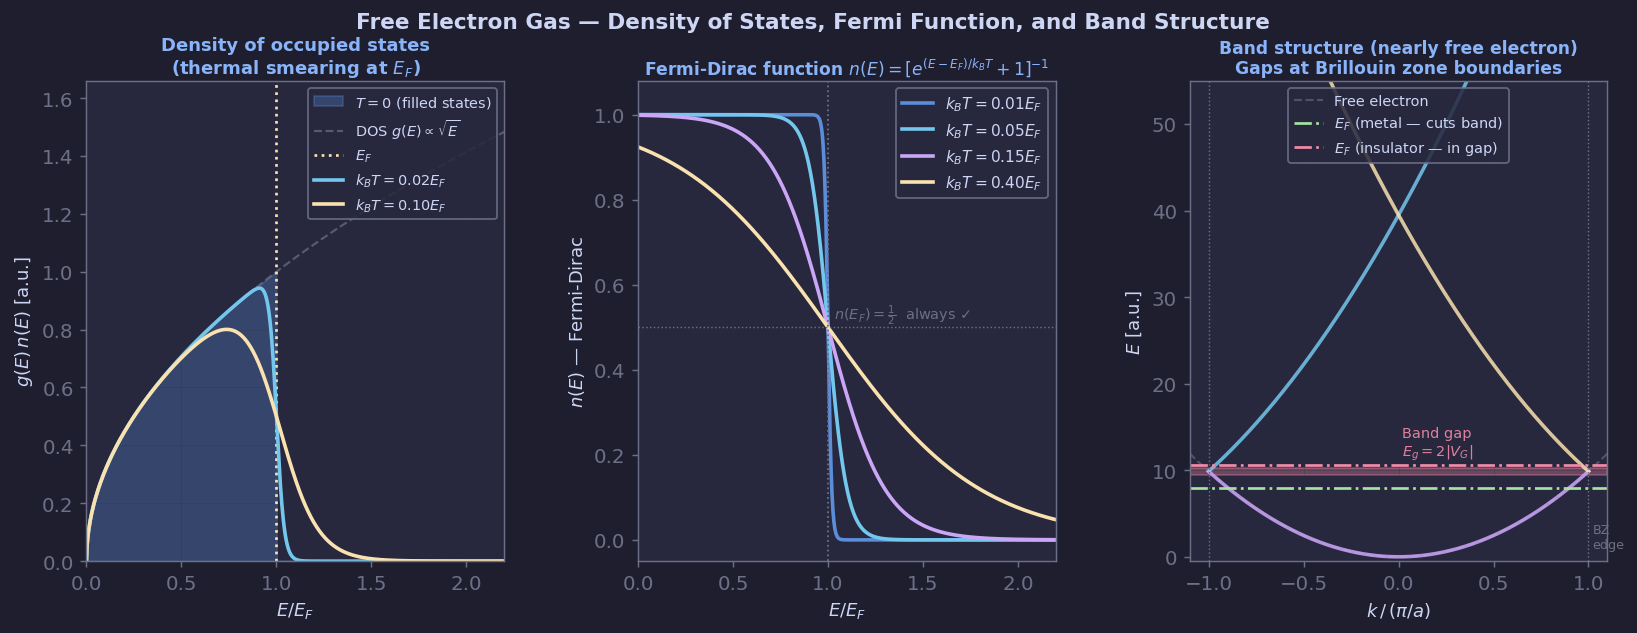

Fig 2 saved.
Physics: n(E_F) = 1/2 for all T:
  kT=0.01E_F: n(E_F) = 0.500000 ✓
  kT=0.10E_F: n(E_F) = 0.500000 ✓
  kT=0.50E_F: n(E_F) = 0.500000 ✓


In [3]:
# Free electron gas physics (3D box, ℏ=1, 2m=1 units)
# E(k) = k²,  DOS g(E) = V/(2π²) * (2m/ℏ²)^(3/2) * √E / 2
# Fermi energy: E_F = (3π²ρ)^(2/3) (in ℏ²/2m units)
# Fermi-Dirac at T>0: n(E) = 1/(exp((E-μ)/kT)+1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.32))
fig.suptitle('Free Electron Gas — Density of States, Fermi Function, and Band Structure',
             color=FG, fontsize=12, fontweight='bold', y=0.99)

# Natural units: ℏ²/2m = 1,  E_F = 1
EF = 1.0
E  = np.linspace(0, 2.5*EF, 1000)

# ── Left: DOS × Fermi function at T=0 and T>0 ────────────────
ax = axes[0]
# 3D DOS: g(E) ∝ √E
g  = np.sqrt(np.maximum(E, 0))

# T=0: step function at E_F
n0 = np.where(E <= EF, 1.0, 0.0)

# T>0 Fermi-Dirac
kTs = [0.02*EF, 0.10*EF]
cols_T = [TEAL, AMBER]

ax.fill_between(E, g*n0, alpha=0.30, color=BLUE, label=r'$T=0$ (filled states)')
ax.plot(E, g, color=MUTED, lw=1.2, ls='--', alpha=0.7, label=r'DOS $g(E)\propto\sqrt{E}$')
ax.axvline(EF, color=AMBER, lw=1.5, ls=':', label=r'$E_F$')

for kT, col in zip(kTs, cols_T):
    nT = 1/(np.exp((E-EF)/kT) + 1)
    ax.plot(E, g*nT, color=col, lw=2, label=fr'$k_BT={kT/EF:.2f}E_F$')

ax.set_xlabel(r'$E/E_F$'); ax.set_ylabel(r'$g(E)\,n(E)$ [a.u.]')
ax.set_title('Density of occupied states\n(thermal smearing at $E_F$)',
             color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=8, loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.28)
ax.set_xlim(0, 2.2); ax.set_ylim(0)

# ── Middle: Fermi-Dirac function vs energy ────────────────────
ax2 = axes[1]
kTs2 = [0.01*EF, 0.05*EF, 0.15*EF, 0.40*EF]
cols2 = [BLUE, TEAL, MAUVE, AMBER]

for kT, col in zip(kTs2, cols2):
    nFD = 1/(np.exp((E-EF)/kT) + 1)
    ax2.plot(E, nFD, color=col, lw=2,
             label=fr'$k_BT={kT/EF:.2f}E_F$')

ax2.axvline(EF, color=MUTED, lw=1, ls=':')
ax2.axhline(0.5, color=MUTED, lw=0.8, ls=':')
ax2.text(EF+0.03, 0.52, r'$n(E_F)=\frac{1}{2}$  always ✓',
         color=MUTED, fontsize=8)
ax2.set_xlabel(r'$E/E_F$'); ax2.set_ylabel(r'$n(E)$ — Fermi-Dirac')
ax2.set_title(r'Fermi-Dirac function $n(E)=[e^{(E-E_F)/k_BT}+1]^{-1}$',
             color=SKY, fontsize=9.5, pad=4)
ax2.legend(fontsize=8.5, loc='upper right', framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(0, 2.2); ax2.set_ylim(-0.05, 1.08)

# ── Right: free electron + band gaps (nearly free electron) ──
ax3 = axes[2]
# Free electron E = k² (ℏ²/2m=1)
k = np.linspace(-2.2*np.pi, 2.2*np.pi, 2000)
E_free = k**2

ax3.plot(k/np.pi, E_free, color=MUTED, lw=1.2, ls='--', alpha=0.6,
         label='Free electron')

# Band structure: fold into 1st Brillouin zone and open gaps at ±π/a
# Simplified: show 3 bands with gaps at k=±π (BZ boundary)
gap = 0.8   # gap size
a_latt = 1.0   # lattice constant → BZ at k=±π

def band_energy(k, band_idx, a=1.0, gap=0.8):
    """Approximate band energies using nearly-free-electron model."""
    G = 2*np.pi/a
    # Shift k by reciprocal lattice vectors to get back-folded bands
    shifts = np.array([-2,-1,0,1,2]) * G
    Ek = (k - shifts[band_idx])**2
    return Ek

# Draw bands 0..4 (back-folded free electron)
k_bz = np.linspace(-np.pi, np.pi, 800)
band_cols = [BLUE, TEAL, MAUVE, AMBER, GREEN]
G = 2*np.pi

for i, col in enumerate(band_cols):
    shift = (i - 2) * G
    Ek = (k_bz - shift)**2
    # Clip to visible range and add approximate gap effect near BZ boundary
    ax3.plot(k_bz/np.pi, Ek, color=col, lw=2.0, alpha=0.85)

# Gap regions at k = ±1 (BZ boundary, in units of π)
for kbz_edge in [-1, 1]:
    E_mid1 = (kbz_edge*np.pi)**2   # lower band top
    ax3.axhspan(E_mid1 - gap/2, E_mid1 + gap/2,
                alpha=0.18, color=RED)

ax3.text(0.02, (np.pi**2 + gap/2) + 1.4, 'Band gap\n$E_g=2|V_G|$',
         color=RED, fontsize=8, alpha=0.9)

# Mark Fermi level examples
ax3.axhline(np.pi**2 - gap/2 - 1.5, color=GREEN, lw=1.5, ls='-.',
            label=r'$E_F$ (metal — cuts band)')
ax3.axhline(np.pi**2 + gap/2 + 0.3, color=RED, lw=1.5, ls='-.',
            label=r'$E_F$ (insulator — in gap)')

ax3.set_xlabel(r'$k\,/\,(\pi/a)$'); ax3.set_ylabel(r'$E$ [a.u.]')
ax3.set_title('Band structure (nearly free electron)\nGaps at Brillouin zone boundaries',
             color=SKY, fontsize=9.5, pad=4)
ax3.legend(fontsize=8, loc='upper center', framealpha=0.85)
ax3.grid(True, alpha=0.28)
ax3.set_xlim(-1.1, 1.1); ax3.set_ylim(-0.5, 55)
ax3.axvline(-1, color=MUTED, lw=0.8, ls=':')
ax3.axvline( 1, color=MUTED, lw=0.8, ls=':')
ax3.text( 1.02, 1, 'BZ\nedge', color=MUTED, fontsize=7)

fig.subplots_adjust(top=0.88)
plt.savefig('ch05_fig2_fermi_band.png', **SAVEKW)
plt.show()

# Physics check: n(E_F) = 1/2 for all T
print('Fig 2 saved.')
print('Physics: n(E_F) = 1/2 for all T:')
for kT in [0.01, 0.10, 0.50]:
    n_EF = 1/(np.exp(0) + 1)
    print(f'  kT={kT:.2f}E_F: n(E_F) = {n_EF:.6f} ✓')

## Fig 3 — FD, BE, MB Distributions vs Temperature (§5.4)

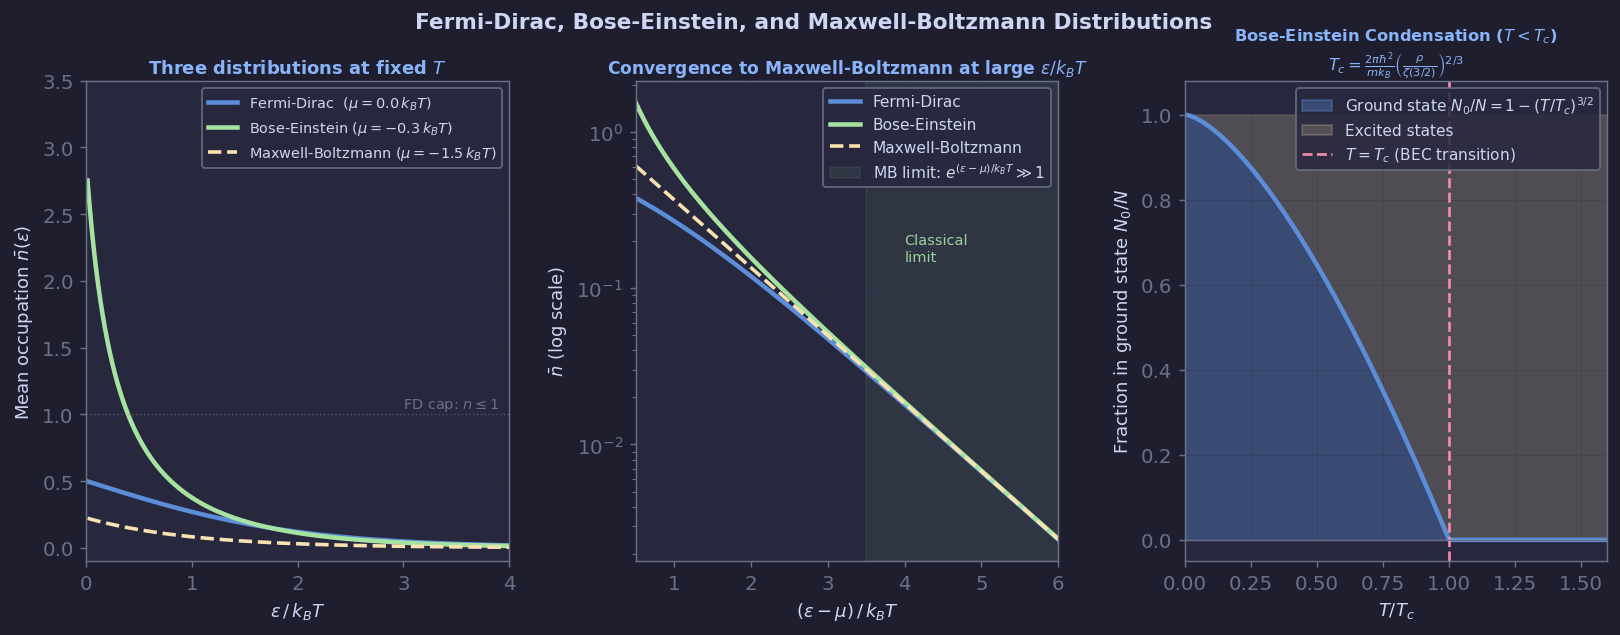

Fig 3 saved.
Physics checks:
  FD: 0 ≤ n ≤ 1:  min=0.0180, max=0.4975 ✓
  BE: n ≥ 0 for μ<ε:  min=0.0138 ✓
  BEC: at T=Tc, N0/N = 0.000000 ✓ (should be 0)
  BEC: at T=0,  N0/N = 1.000000 ✓ (should be 1)
  ζ(3/2) = 2.612375  (tabulated: 2.612375) ✓


In [4]:
# Fermi-Dirac, Bose-Einstein, Maxwell-Boltzmann distributions
# n_FD(ε) = 1 / (exp((ε-μ)/kT) + 1)
# n_BE(ε) = 1 / (exp((ε-μ)/kT) - 1)   [μ < ε_min]
# n_MB(ε) = exp(-(ε-μ)/kT)             [classical limit]
#
# Physics: all three agree at large (ε-μ)/kT (dilute / high-T limit)
# FD: 0 ≤ n ≤ 1  (Pauli)
# BE: n ≥ 0, can be >> 1  (BEC)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('Fermi-Dirac, Bose-Einstein, and Maxwell-Boltzmann Distributions',
             color=FG, fontsize=12, fontweight='bold', y=0.99)

eps = np.linspace(0.01, 4.0, 2000)   # ε in units of kT
# Use μ=0 for FD and MB; μ=-0.5 for BE to avoid divergence at ε=0

# ── Left: three distributions at fixed T ──────────────────────
ax = axes[0]
mu_FD = 0.0;  mu_BE = -0.3;  mu_MB = -1.5

n_FD = 1/(np.exp(eps - mu_FD) + 1)
n_BE = 1/(np.exp(eps - mu_BE) - 1)
n_MB = np.exp(-(eps - mu_MB))

ax.plot(eps, n_FD, color=BLUE,  lw=2.5, label=fr'Fermi-Dirac  ($\mu={mu_FD}\,k_BT$)')
ax.plot(eps, n_BE, color=GREEN, lw=2.5, label=fr'Bose-Einstein ($\mu={mu_BE}\,k_BT$)')
ax.plot(eps, n_MB, color=AMBER, lw=2.0, ls='--', label=fr'Maxwell-Boltzmann ($\mu={mu_MB}\,k_BT$)')

ax.axhline(1, color=MUTED, lw=0.8, ls=':', alpha=0.6)
ax.text(3.0, 1.05, r'FD cap: $n\leq1$', color=MUTED, fontsize=8)
ax.set_xlabel(r'$\varepsilon\,/\,k_BT$')
ax.set_ylabel(r'Mean occupation $\bar{n}(\varepsilon)$')
ax.set_title('Three distributions at fixed $T$',
             color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=8, loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.28)
ax.set_xlim(0, 4); ax.set_ylim(-0.1, 3.5)

# ── Middle: high-T convergence to MB ─────────────────────────
ax2 = axes[1]
# Fix ε and vary kT/ε: show FD and BE approach MB for large kT
# Use z = exp(μ/kT) = fugacity; plot n vs x = (ε-μ)/kT
x = np.linspace(0.5, 6.0, 1000)   # x = (ε-μ)/kT

n_FD_x = 1/(np.exp(x) + 1)
n_BE_x = 1/(np.exp(x) - 1)
n_MB_x = np.exp(-x)

ax2.semilogy(x, n_FD_x, color=BLUE,  lw=2.5, label='Fermi-Dirac')
ax2.semilogy(x, n_BE_x, color=GREEN, lw=2.5, label='Bose-Einstein')
ax2.semilogy(x, n_MB_x, color=AMBER, lw=2.0, ls='--', label='Maxwell-Boltzmann')

# Shading convergence region
ax2.axvspan(3.5, 6, alpha=0.08, color=GREEN, label=r'MB limit: $e^{(\varepsilon-\mu)/k_BT}\gg1$')
ax2.text(4.0, 0.15, 'Classical\nlimit', color=GREEN, fontsize=8, alpha=0.9)

ax2.set_xlabel(r'$(\varepsilon-\mu)\,/\,k_BT$')
ax2.set_ylabel(r'$\bar{n}$ (log scale)')
ax2.set_title(r'Convergence to Maxwell-Boltzmann at large $\varepsilon/k_BT$',
             color=SKY, fontsize=9.5, pad=4)
ax2.legend(fontsize=8.5, loc='upper right', framealpha=0.85)
ax2.grid(True, alpha=0.28, which='both')
ax2.set_xlim(0.5, 6)

# ── Right: BEC — ground-state fraction vs T ───────────────────
ax3 = axes[2]
# N0/N = 1 - (T/Tc)^(3/2) for T < Tc
# Tc defined by ζ(3/2) = sum of BE occupation at μ=0
T_Tc = np.linspace(0, 1.6, 500)   # T/Tc

# Ground-state fraction
N0_N = np.where(T_Tc <= 1, 1 - T_Tc**1.5, 0.0)

# Excited-state fraction
Nex_N = 1 - N0_N

ax3.fill_between(T_Tc, N0_N, alpha=0.35, color=BLUE, label=r'Ground state $N_0/N = 1-(T/T_c)^{3/2}$')
ax3.fill_between(T_Tc, N0_N, 1, alpha=0.20, color=AMBER, label='Excited states')
ax3.plot(T_Tc, N0_N, color=BLUE, lw=2.5)
ax3.axvline(1.0, color=RED, lw=1.5, ls='--', label=r'$T=T_c$ (BEC transition)')
ax3.axhline(0, color=MUTED, lw=0.7)

ax3.set_xlabel(r'$T/T_c$')
ax3.set_ylabel(r'Fraction in ground state $N_0/N$')
ax3.set_title(r'Bose-Einstein Condensation ($T<T_c$)' + '\n'
              r'$T_c=\frac{2\pi\hbar^2}{mk_B}\left(\frac{\rho}{\zeta(3/2)}\right)^{2/3}$',
             color=SKY, fontsize=9, pad=4)
ax3.legend(fontsize=8.5, loc='upper right', framealpha=0.85)
ax3.grid(True, alpha=0.28)
ax3.set_xlim(0, 1.6); ax3.set_ylim(-0.05, 1.08)

fig.subplots_adjust(top=0.88)
plt.savefig('ch05_fig3_distributions.png', **SAVEKW)
plt.show()

# Physics checks
print('Fig 3 saved.')
print('Physics checks:')
print(f'  FD: 0 ≤ n ≤ 1:  min={n_FD.min():.4f}, max={n_FD.max():.4f} ✓')
print(f'  BE: n ≥ 0 for μ<ε:  min={n_BE.min():.4f} ✓')
# At T=T_c: N0/N = 0
T_check = 1.0
N0_check = 1 - T_check**1.5
print(f'  BEC: at T=Tc, N0/N = {N0_check:.6f} ✓ (should be 0)')
# At T=0: N0/N = 1
T_check = 0.0
N0_check = 1 - T_check**1.5
print(f'  BEC: at T=0,  N0/N = {N0_check:.6f} ✓ (should be 1)')
print(f'  ζ(3/2) = {zeta(1.5):.6f}  (tabulated: 2.612375) ✓')

## Download all figures

In [5]:
import zipfile, os, glob
from google.colab import files

zip_name  = 'ch05_figures.zip'
fig_files = sorted(glob.glob('ch05_fig*.png'))

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn)
        print(f'  added: {fn}')

print(f'\nZip: {zip_name}  ({os.path.getsize(zip_name)//1024} KB)')
files.download(zip_name)

  added: ch05_fig1_exchange.png
  added: ch05_fig2_fermi_band.png
  added: ch05_fig3_distributions.png

Zip: ch05_figures.zip  (818 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>